# GP-PHS: double-well oscillator

Pipeline: **GP smoother** → **GP-PHS training** → **Hamiltonian posterior** → **trajectory**.

$$
H(\theta, p) = \frac{p^2}{2} + \frac{\theta^2}{4} + 2\cos\theta
\qquad
\dot{x} = (J-R)\nabla H
$$

| Matrix | Value |
|----------|----------|
| $J$ | $\begin{bmatrix}0 & 1 \\ -1 & 0\end{bmatrix}$ |
| $R$ | $\operatorname{diag}(0,\; b)$ with **$b$ unknown** |
| $G$ | $\begin{bmatrix}0 \\ 1\end{bmatrix}$ |


### Install (Colab only)
Skip this step when running locally.

In [ ]:
# ── Google Colab / fresh environment setup ──────────────────────────────────
!pip install -q git+https://github.com/essey1/neuromancer.git gpytorch scipy

## Imports

In [1]:
# imports
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve() / "src"))

import torch
import numpy as np
import matplotlib.pyplot as plt
import gpytorch
from scipy.integrate import odeint
from torch.utils.data import DataLoader

from neuromancer import psl
from neuromancer import dataset
from neuromancer.psl import plot
from neuromancer.dynamics import gp_phs, ode
from neuromancer.psl import gp_smoother
from neuromancer.modules import hamiltonian_approximator
from neuromancer.system import Node, System
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.loggers import BasicLogger

torch.manual_seed(0); np.random.seed(0)

## Configuration

In [2]:
# config
B_TRUE   = 0.03   # true damping (model starts at 0.5)
N_POINTS = 100    # training observations
NOISE    = 0.1    # sensor noise std
N_EPOCHS = 2000
NX, NU   = 2, 1
T_SIM    = 25.0
X0_SIM   = [5, 0.0]

## True system

### Define dynamics

In [3]:
# define system and simulate
JR_true = np.array([[0., 1.], [-1., -B_TRUE]])

def H_true(theta, p):      return 0.5*p**2 + 0.25*theta**2 + 2*np.cos(theta)
def grad_H_true(theta, p): return np.stack([0.5*theta - 2*np.sin(theta), p], axis=-1)
def dynamics(state, _):    return JR_true @ grad_H_true(state[0], state[1])

t_full    = np.linspace(0, 25.0, 1000)
traj_full = odeint(dynamics, [5.0, 0.0], t_full)
H_full    = H_true(traj_full[:, 0], traj_full[:, 1])

### Plot

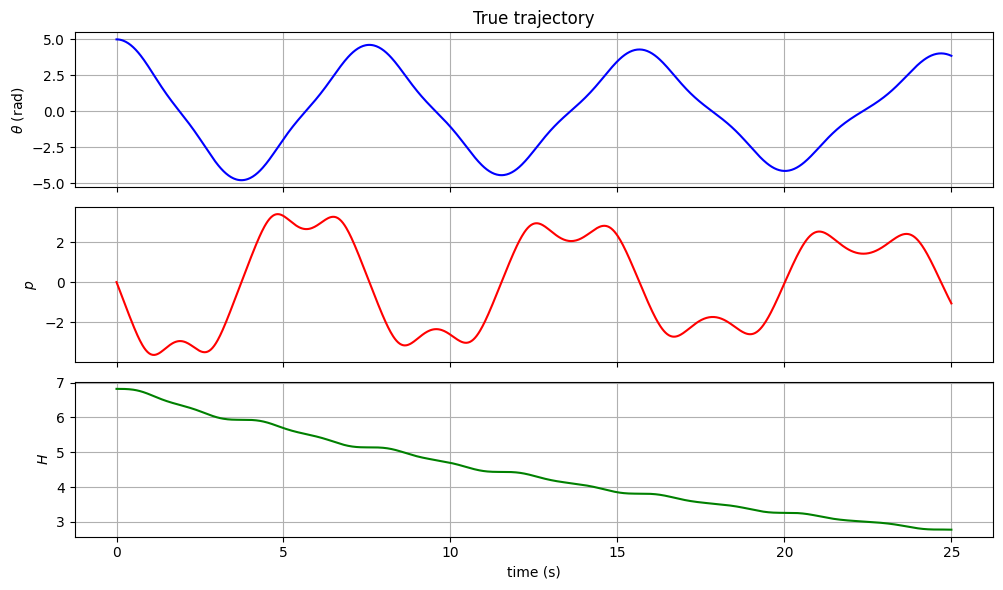

In [4]:
# plot — states and energy
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for i, (ax, lbl, col) in enumerate(zip(axes[:2], [r'$\theta$ (rad)', '$p$'], ['b', 'r'])):
    ax.plot(t_full, traj_full[:, i], col); ax.set_ylabel(lbl); ax.grid(True)
axes[2].plot(t_full, H_full, 'g'); axes[2].set_ylabel('$H$'); axes[2].grid(True)
axes[2].set_xlabel('time (s)'); axes[0].set_title('True trajectory')
plt.tight_layout(); plt.show()

## Step 1: Dataset Preparation

In [5]:
# DATA GENERATION
t_np = np.linspace(0, T_SIM, N_POINTS)
x_i = odeint(dynamics, X0_SIM, t_np)
u_i = np.zeros((N_POINTS, NU))
x_noisy_i = x_i + np.random.normal(0, NOISE, x_i.shape)

# GP SMOOTHER
x_smooth, xdot_smooth, xdot_var_np = gp_smoother.gp_smooth(t_np, x_noisy_i)

# DATA LOADERS
train_loader, dev_loader, test_loader = dataset.gpphs_data_from_arrays(
    x=x_smooth,
    x_dot=xdot_smooth,
    u=u_i,
    x_dot_var=xdot_var_np,
    split_ratio=[75.0, 15.0, 10.0],
    batch_size=N_POINTS,
)

C:\Users\arayae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)
C:\Users\arayae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gpytorch\models\exact_gp.py:299: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


### Plot

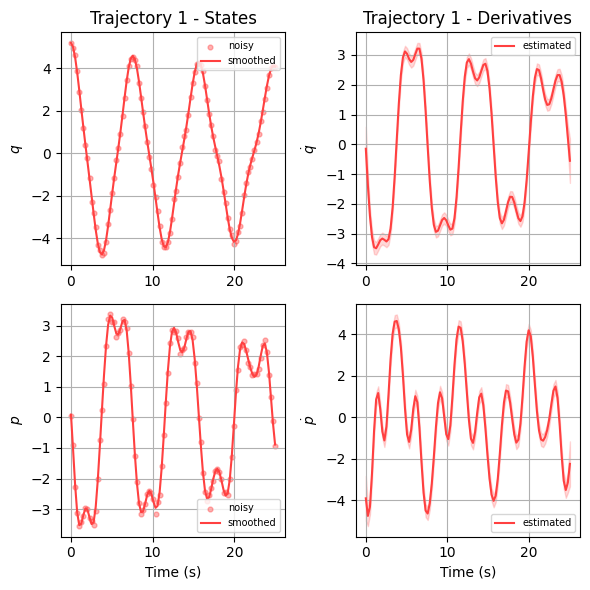

In [6]:
plot.pltGPSmooth(
    [t_np],
    [x_noisy_i],
    [x_smooth],
    [xdot_smooth],
    [xdot_var_np],
    state_lbls=[r'$q$', r'$p$'],
    deriv_lbls=[r'$\dot{q}$', r'$\dot{p}$'],
)

## Step 2: PHS structure

Unknown damping parameterized as $b = \exp(\tilde{b})$ (ensures $b > 0$).

In [7]:
# Step 2: PHS Structure
b = gp_phs.positive_param('b', 0.5)

phs = gp_phs.PHSMatrices(
    nx=NX, nu=NU,
    J_upper={(0, 1): lambda x: torch.ones(x.shape[0])},
    R_diag={
        0: lambda x: torch.zeros(x.shape[0]),
        1: lambda x: gp_phs.recover(b) * torch.ones(x.shape[0])
    },
    G_full={
        (0, 0): lambda x: torch.zeros(x.shape[0]),
        (1, 0): lambda x: torch.ones(x.shape[0])
    },
)

## Step 3: Build Node, Loss, and Problem

In [8]:
# Build node, loss, and problem
gpphs_module = gp_phs.GPPHSNode(phs, NX, NU)
gpphs_node = Node(gpphs_module, ['X', 'U', 'Xdot', 'Xdot_var'], ['nlml'], name='gp_phs')

# Symbolic variable
nlml = variable('nlml')

# Objective: minimise the negative log marginal likelihood
nlml_loss = nlml.minimize()
nlml_loss.name = 'nlml_loss'

# Aggregate objectives and constraints
objectives = [nlml_loss]
constraints = []

# Loss + problem
loss = PenaltyLoss(objectives, constraints)
problem = Problem([gpphs_node], loss)

print('Problem created with:')
print(f'  {len(list(problem.parameters()))} total parameters')
print(f'  Objectives: {len(objectives)}')
print(f'  Constraints: {len(constraints)}')

Problem created with:
  4 total parameters
  Objectives: 1
  Constraints: 0


## Step 4: Training

In [9]:
optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)
logger    = BasicLogger(args=None, savedir='test', verbosity=1,
                        stdout=['train_loss', 'dev_loss'])
trainer   = Trainer(
    problem,
    train_loader,
    dev_loader,
    optimizer,
    epochs=N_EPOCHS,
    patience=N_EPOCHS,
    train_metric='train_loss',
    dev_metric='dev_loss',
    eval_metric='dev_loss',
    logger=logger,
)

None
Number of parameters: 5


In [10]:
best_model = trainer.train()
problem.load_state_dict(best_model)

epoch: 0	train_loss: 677.69061	dev_loss: 55.39957	eltime:  0.03886
epoch: 1	train_loss: 647.58020	dev_loss: 55.48937	eltime:  0.05219
epoch: 2	train_loss: 619.34222	dev_loss: 55.58340	eltime:  0.06478
epoch: 3	train_loss: 592.92993	dev_loss: 55.68126	eltime:  0.07663
epoch: 4	train_loss: 568.30505	dev_loss: 55.78265	eltime:  0.08864
epoch: 5	train_loss: 545.42023	dev_loss: 55.88736	eltime:  0.10015
epoch: 6	train_loss: 524.21252	dev_loss: 55.99519	eltime:  0.11316
epoch: 7	train_loss: 504.60492	dev_loss: 56.10606	eltime:  0.12652
epoch: 8	train_loss: 486.52905	dev_loss: 56.21993	eltime:  0.13876
epoch: 9	train_loss: 469.90253	dev_loss: 56.33686	eltime:  0.14961
epoch: 10	train_loss: 454.65057	dev_loss: 56.45691	eltime:  0.16280
epoch: 11	train_loss: 440.68622	dev_loss: 56.58015	eltime:  0.17649
epoch: 12	train_loss: 427.92358	dev_loss: 56.70670	eltime:  0.18798
epoch: 13	train_loss: 416.28241	dev_loss: 56.83662	eltime:  0.20884
epoch: 14	train_loss: 405.68573	dev_loss: 56.96997	eltime:

<All keys matched successfully>

### Parameter Recovery

In [11]:
gp_phs.param_table({
    'b': (b, B_TRUE),
})

Parameter  True  Learned  Rel. Error %
        b  0.03  0.03348     11.600444

Mean relative error:   11.60%
Median relative error: 11.60%


,Parameter,True,Learned,Rel. Error %
0,b,0.03,0.03348,11.600444


## Step 5: Hamiltonian posterior

$H$ is identifiable up to an additive constant; the posterior mean is aligned to the true $H$ at training points.

### Compute Posterior

In [12]:
# Build GP posterior
posterior = gpphs_node.callable.posterior()

# Compute Hamiltonian posterior
H_mean, H_var, H_samples = posterior.predict(
    [x_smooth],
    [u_i],
    [xdot_smooth],
    [xdot_var_np],
    n_samples=50,
)

# True Hamiltonian for comparison
H_true_traj = np.array([
    H_true(*row) for row in x_smooth
])

### Plot

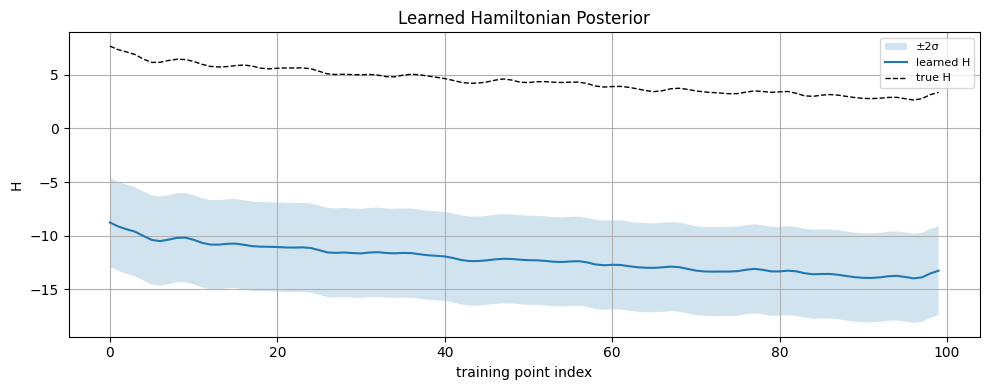

In [13]:
# Plot Hamiltonian posterior vs true
plot.pltHamiltonian(H_mean.numpy(), H_var.numpy(), H_true=H_true_traj)

## Step 6: Callable $H^*$

Fit a GP interpolant to each posterior sample so $H^*$ can be evaluated and differentiated anywhere.

### Fit ensemble

In [14]:
x_smooth_t = torch.tensor(x_smooth, dtype=torch.float32)

ensemble = [
    hamiltonian_approximator.HamiltonianApproximator(
        method='gp',
        lengthscale=posterior.lengthscale,
        signal_var=posterior.signal_var,
    ).fit(x_smooth_t, H_samples[i])
    for i in range(H_samples.shape[0])
]

## Step 7: Derivative Prediction

Verify that the learned model predicts $\dot{x} = (J(x) - R(x))\nabla H^*(x)$ correctly at training points before committing to full trajectory rollout.

In [15]:
xdot_true = xdot_smooth
u_traj1   = u_i

# EVALUATE LEARNED DYNAMICS: ẋ = (J(x) - R(x))∇H*(x) + G(x)u
JR             = (phs.get_J(x_smooth_t) - phs.get_R(x_smooth_t)).detach().numpy()
G              = phs.get_G(x_smooth_t).detach().numpy()
grad_H_stack   = torch.stack([h.gradient(x_smooth_t) for h in ensemble])
grad_H_mean    = grad_H_stack.mean(0).detach().numpy()
grad_H_std     = grad_H_stack.std(0).detach().numpy()
xdot_pred      = np.einsum('nij,nj->ni', JR, grad_H_mean) + np.einsum('nij,nj->ni', G, u_traj1)
xdot_pred_std  = np.einsum('nij,nj->ni', JR, grad_H_std)

### Plot

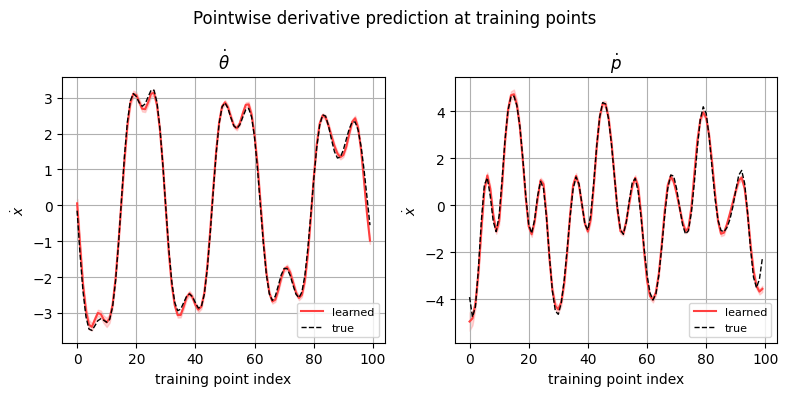

In [16]:
plot.pltXdot(
    xdot_pred, xdot_true,
    xdot_std=xdot_pred_std,
    state_lbls=[r'$\dot{\theta}$', r'$\dot{p}$'],
)

## Step 8: Trajectory prediction

Simulate 10 trajectories (one per $H^*$ sample). Shaded band = $\pm 2$ std across the ensemble.

### Simulate

In [17]:
dt    = 0.01
t_sim = np.arange(0.0, T_SIM + dt, dt)

# True reference trajectory
traj_sim = odeint(
    dynamics,
    [5.0, 0.0], t_sim,
)

# Control input: (T, batch=1, nu=1)
u_sim = torch.zeros(len(t_sim), 1, NU, dtype=torch.float32)

# Simulate learned GP-PHS
phsode = ode.PHSODE(phs, ensemble, NX, NU, method='rk4')
with torch.no_grad():
    result = phsode.simulate(
        x0=torch.tensor([[5.0, 0.0]], dtype=torch.float32),
        t_span=(0.0, T_SIM),
        u=u_sim,
        dt=dt,
    )

t_gp = result['t_eval'].numpy()
mean = result['mean'][:, 0, :].numpy()
std  = result['std'][:, 0, :].numpy()

### Plot

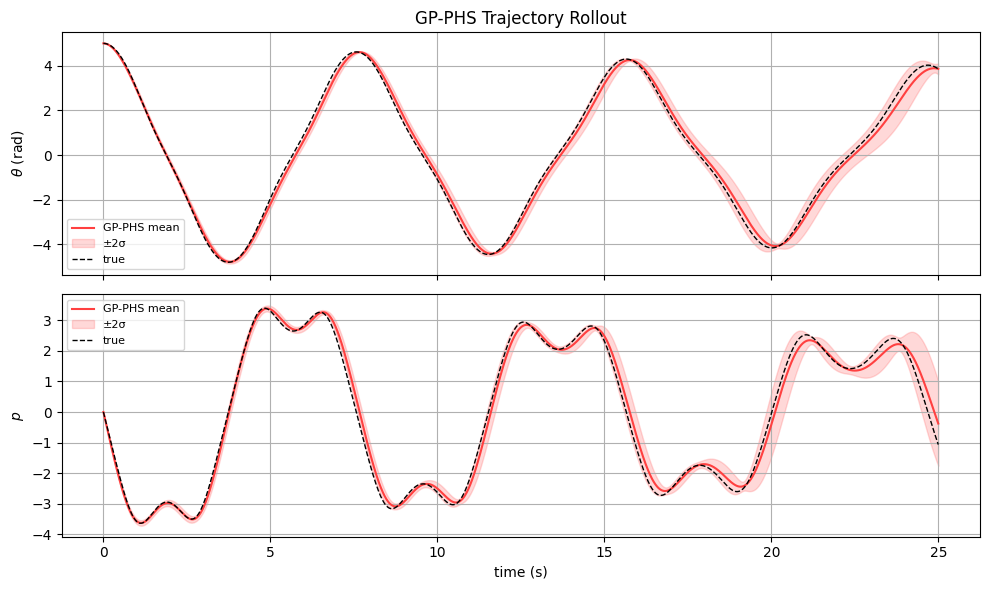

In [18]:
plot.pltTrajectory(t_gp, mean, std=std, x_true=traj_sim,
                   state_lbls=[r'$\theta$ (rad)', '$p$'])